In [13]:
import numpy as np
from scipy.io import loadmat
import warnings
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

In [2]:
!pip install pandas
!pip install resonator_tools

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root, least_squares
from scipy.special import ellipk
from scipy.constants import mu_0, epsilon_0
from resonator_tools import circuit

In [4]:
df = pd.read_csv('TC-Main-001-resonator-tools-fit-results.csv')

In [5]:
def del_sol(delta, a, phi_ext_val):
    return delta + a * np.sin(delta) - phi_ext_val

def solve_delta(phi_ext, a):
    """Solve delta + a*sin(delta) = phi_ext, sweeping in phi_ext order for warm-start continuity."""
    phi_ext = np.asarray(phi_ext)
    delta = np.zeros_like(phi_ext, dtype=float)
    order = np.argsort(phi_ext)
    d0 = 0.0
    for idx in order:
        sol = root(del_sol, d0, args=(a, phi_ext[idx]))
        delta[idx] = sol.x[0]
        d0 = sol.x[0]
    return delta

def Z_L(L_01, L_02, L_T, d, w, R):
    ZL01 = 1j * w * L_01
    ZL02 = 1j * w * L_02
    ZLT = 1j * w * L_T / np.cos(d)
    ZL02R = (1/ZL02 + 1/R)**(-1)
    ZSQUID = (1/ZL01 + 1/(ZLT + ZL02R))**(-1)
    return ZSQUID

def Z_tot(ZL, Z0, beta, l, c_c, w):
    x = beta * l
    Z_c = 1 / (1j * w * c_c)
    return (Z0 * ((ZL + 1j*Z0*np.tan(x)) / (Z0 + 1j*ZL*np.tan(x)))) + Z_c

def S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, Z0=50):
    """
    X = (I, f): current (A) and frequency (Hz) arrays, same length (elementwise pairs).
    Fit params: L0 (=L01=L02), LT, L_l, C_l, C_c, R_j
    Fixed:      l_f (resonator length), M, O (current -> flux calibration)
    """
    I, f = X
    w = 2 * np.pi * f
    phi_ext = M * I + O

    a = 2 * L0 / LT
    delta = solve_delta(phi_ext, a)

    beta = w * np.sqrt(L_l * C_l)
    ZL = Z_L(L0, L0, LT, delta, w, R_j)
    Ztot = Z_tot(ZL, Z0, beta, l_f, C_c, w)

    return 2 / (2 + Z0 / Ztot)

In [6]:
def calc_cpw_param_set(center_width, gap_width, substrate_r, metal_thickness):
    a = center_width / 2
    b = center_width / 2 + gap_width
    d = metal_thickness / (2 * np.pi)

    u1 = a + d/2 + 1.5*np.log(2)*d - d/2*np.log(d/a) + d/2*np.log((b-a)/(a+b))
    u2 = b - d/2 - 1.5*np.log(2)*d + d/2*np.log(d/a) + d/2*np.log((b-a)/(a+b))
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    c = 2 * epsilon_0 * ellipk(k1) / ellipk(k2) * (1 + substrate_r)

    d = d / 2
    u1 = a + d/2 + 1.5*np.log(2)*d - d/2*np.log(d/a) + d/2*np.log((b-a)/(a+b))
    u2 = b - d/2 - 1.5*np.log(2)*d + d/2*np.log(d/a) + d/2*np.log((b-a)/(a+b))
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    l = mu_0/4 * ellipk(k2) / ellipk(k1)

    lambda_eff = 50e-9
    k = a / b
    g_ctr = 1/(4*a*ellipk(k)**2*(1-k)**2) * (np.pi + np.log(4*np.pi*a/metal_thickness) - k*np.log((1+k)/(1-k)))
    g_gnd = 1/(4*a*ellipk(k)**2*(1-k)**2) * (np.pi + np.log(4*np.pi*b/metal_thickness) - k*np.log((1+k)/(1-k)))
    l_ki = (g_ctr + g_gnd) * mu_0 * lambda_eff

    return {'inductance': l + l_ki, 'capacitance': c}

def calc_target_length(target_frequency, cpw_param_set):
    return 1e6 / (4 * target_frequency * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))

res_cpw_param_set = calc_cpw_param_set(
    center_width=10e-6, gap_width=7e-6, substrate_r=11.6, metal_thickness=200e-9
)
R_L = calc_target_length(5.5e9, res_cpw_param_set) / 1e6   # resonator length, fixed (not fitted)
L_l = res_cpw_param_set['inductance']
C_l = res_cpw_param_set['capacitance']
R_L, L_l, C_l

(np.float64(0.005122618693762872),
 np.float64(5.074157785774444e-07),
 np.float64(1.5516958921654498e-10))

In [7]:
df = pd.read_csv('TC-Main-001-resonator-tools-fit-results.csv')

X = df['Ql'].copy()
X[146] = X[145]
X[90] = X[89]

Y = df['Qi'].copy()
Y[146] = Y[145]
Y[90] = Y[89]

Z = df['Qc'].copy()
Z[146] = Z[145]
Z[90] = Z[89]

F = df['f0'].copy()

I_data = df['I'].to_numpy()   # same raw current units used throughout this project

X = X.to_numpy(); Y = Y.to_numpy(); Z = Z.to_numpy(); F = F.to_numpy()
print(f"Loaded {len(I_data)} traces.")

Loaded 216 traces.


In [14]:
def lorentzian_dip_power(f, f0, Q_L, baseline, Q_e_inv):
    """
    Fit model for |S21|^2 in terms of Q factors directly.
    Q_e_inv = 1/Q_e (easier to fit as a free parameter)
    """
    depth_amplitude = Q_L * Q_e_inv          # = Q_L / Q_e
    lorentz = depth_amplitude / (1 + 4 * Q_L**2 * ((f - f0)/f0)**2)
    # |S21|^2 = baseline * |1 - lorentz|^2
    return baseline * (1 - lorentz)**2


def calculate_q_factors(freq, S21_vals):

    # Ensure freq is a flat 1D array
    #freq = np.asarray(freq).flatten()
    n_flux = S21_vals.shape[1]
    
    q_loaded = np.zeros(n_flux)
    q_internal = np.zeros(n_flux)
    q_external = np.zeros(n_flux)
    f0_fits = np.zeros(n_flux)
    
    for i in range(n_flux):
        power = np.abs(S21_vals[:, i])**2
        
        baseline_guess = np.max(power)
        min_idx = np.argmin(power)
        f0_guess = freq[min_idx]
        S21_min = np.sqrt(power[min_idx] / baseline_guess)
        
        # Estimate df (FWHM) by finding points below the half-depth
        half_max = baseline_guess - (baseline_guess - power[min_idx]) / 2.0
        below_half = np.where(power < half_max)[0]
        
        df_guess = freq[below_half[-1]] - freq[below_half[0]]

        Q_L_guess = f0_guess/df_guess
        
        dip = np.clip(1.0-S21_min, 1e-6, 2.0)
        Qe_inv_guess = dip/Q_L_guess
                 
        p0 = [f0_guess, Q_L_guess, baseline_guess, Qe_inv_guess]
        
        popt, _ = curve_fit(lorentzian_dip_power, freq, power,
                            p0=p0, maxfev=2000)
        f0_fit, Q_L_fit, _, Qe_inv_fit = popt
        Q_L_fit = np.abs(Q_L_fit)
        Q_e_fit = 1.0 / np.abs(Qe_inv_fit)
        
        Q_i_fit = 1.0 / (1.0/Q_L_fit - 1.0/Q_e_fit)

        q_loaded[i]   = Q_L_fit
        q_external[i] = Q_e_fit
        q_internal[i] = Q_i_fit
        f0_fits[i]    = f0_fit

    return q_loaded, q_internal, q_external, f0_fits

In [26]:
def model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, f_bounds, n_freq=400):
    """Generate dense model S21 per current, extract Q_i/Q_ext/f0 via the same
    Lorentzian-fit machinery used on the real data."""
    f_dense = np.linspace(*f_bounds, n_freq)
    S21_grid = np.zeros((n_freq, len(I_arr)), dtype=complex)

    for k, I_val in enumerate(I_arr):
        S21_grid[:, k] = S21_fit_func(
            (np.full(n_freq, I_val), f_dense),
            L0, LT, L_l, C_l, C_c, R_j, M, O, l_f
        )

    q_L, q_i, q_e, f0_arr = calculate_q_factors(f_dense, S21_grid)
    return q_L, q_i, q_e, f0_arr

In [8]:
import warnings

def model_q_factors_rt(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, f_bounds, n_freq=300):
    f_dense = np.linspace(*f_bounds, n_freq)

    q_L = np.full(len(I_arr), np.nan)
    q_i = np.full(len(I_arr), np.nan)
    q_c = np.full(len(I_arr), np.nan)
    f0_arr = np.full(len(I_arr), np.nan)

    for k, I_val in enumerate(I_arr):
        z = S21_fit_func((np.full(n_freq, I_val), f_dense), L0, LT, L_l, C_l, C_c, R_j, M, O, l_f)

        port = circuit.notch_port()
        port.add_data(f_dense, z)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("error", RuntimeWarning)   # treat as failure, not garbage output
                port.autofit(electric_delay=0.0)
        except Exception:
            continue   # leaves NaN -> penalized by safe_log_residual, as intended

        res_d = getattr(port, 'fitresults', None)
        if not isinstance(res_d, dict):
            continue

        f0_arr[k] = res_d.get('fr', np.nan)
        q_L[k] = res_d.get('Ql', np.nan)
        Qc = res_d.get('Qc_dia_corr', res_d.get('absQc', np.nan))
        q_c[k] = Qc
        Qi = res_d.get('Qi_dia_corr', res_d.get('Qi', np.nan))
        if not np.isfinite(Qi) and np.isfinite(q_L[k]) and np.isfinite(Qc) and Qc > q_L[k]:
            Qi = (q_L[k] * Qc) / (Qc - q_L[k])
        q_i[k] = Qi

    return q_L, q_i, q_c, f0_arr

In [27]:
def summary_residuals_QL_f0(params, I_arr, QL_data, f0_data, Qext_all,l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)

    # w = pole_weights(I_arr*1e6, M, O_fixed)

    res_QL = (np.log10(q_L) - np.log10(QL_data)) #* w
    res_f0 = ((f0 - f0_data) / 1e6) #* w
    #res_Qe = (np.log10(q_e) - np.log10(Qext_all)) #* w

    return np.concatenate([res_QL, res_f0])


O_fixed = np.pi - 1.25
M_mag = 2*np.pi / 2.15e-6  
#L_l = 4.9137e-7
#C_l = 1.2861e-10

p0 = [0.17e-9, 0.38e-9, L_l, C_l, 64e-15, 18, M_mag]
lower = [0.15e-9, 0.37e-9, 0.6*L_l, 0.6*C_l, 62e-15, 15,  -1.1*M_mag]
upper = [0.18e-9, 0.42e-9, 1.1*L_l, 1.1*C_l, 70e-15, 20, 1.1*M_mag]

res = least_squares(
    summary_residuals_QL_f0, p0,
    args = (I_data*1e-6, X, F, Z, R_L, (df['f0'].min()*0.97, df['f0'].max()*1.03), O_fixed),
    bounds=(lower, upper), x_scale='jac'
)

# res = least_squares(
#     summary_residuals_rt, p0,
#     args=(I_data*1e-6, X, F, Z, R_L, (df['f0'].min()*0.97, df['f0'].max()*1.03), O_fixed),
#     bounds=(lower, upper), x_scale='jac'
# )
L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f = res.x
print(res.x, " a =", 2*L0_f/LT_f, " cost:", res.cost)

[1.67938290e-10 4.13458709e-10 4.92857040e-07 1.23828618e-10
 6.61230080e-14 1.95977817e+01 2.89984360e+06]  a = 0.8123582195797042  cost: 17890.437215422433


In [24]:
def summary_residuals_rt(params, I_arr, QL_data, f0_data, Qc_data, l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    q_L, q_i, q_c, f0 = model_q_factors_rt(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)

    # any failed/NaN points get a fixed, large penalty instead of NaN propagating into the optimizer
    def safe_log_residual(model_val, data_val):
        bad = ~np.isfinite(model_val) | ~np.isfinite(data_val) | (model_val <= 0) | (data_val <= 0)
        res = np.where(bad, 5.0, np.log10(np.where(bad, 1.0, model_val)) - np.log10(np.where(bad, 1.0, data_val)))
        return res

    res_QL = safe_log_residual(q_L, QL_data)
    res_qc = safe_log_residual(q_c, Qc_data)

    bad_f0 = ~np.isfinite(f0) | ~np.isfinite(f0_data)
    res_f0 = np.where(bad_f0, 1e3, (np.where(bad_f0, 0, f0) - f0_data) / 1e6)

    return np.concatenate([res_QL, res_f0, res_qc])


O_fixed = np.pi - 1.25
M_mag = 2*np.pi / 2.15e-6

p0 = [0.18e-9, 0.45e-9, L_l, C_l, 52e-15, 15, M_mag]
lower = [0.16e-9, 0.43e-9, 0.6*L_l, 0.6*C_l, 30e-15, 10,  -1.1*M_mag]
upper = [0.2e-9, 0.52e-9, 1.1*L_l, 1.1*C_l, 60e-15, 20, 1.1*M_mag]

res = least_squares(
    summary_residuals_rt, p0,
    args=(I_data*1e-6, X, F, Z, R_L, (df['f0'].min()*0.97, df['f0'].max()*1.03), O_fixed),
    bounds=(lower, upper), x_scale='jac'
)

L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f = res.x
print(res.x, " a =", 2*L0_f/LT_f, " cost:", res.cost)

[1.80000000e-10 4.75000000e-10 5.07415779e-07 1.31894151e-10
 4.50000000e-14 1.50000000e+01 2.92241177e+06]  a = 0.7578947368421053  cost: 13547272.211028084


In [10]:
failed_currents = []
for I_val in np.linspace(-0.66e-6, 1.49e-6, 50):
    f_dense = np.linspace(4.6e9, 5.6e9, 300)
    z = S21_fit_func((np.full(300, I_val), f_dense), *res.x, O_fixed, R_L)
    port = circuit.notch_port()
    port.add_data(f_dense, z)
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        try:
            port.autofit(electric_delay=0.0)
        except Exception:
            pass
        if len(w) > 0:
            failed_currents.append(I_val*1e6)

print("Currents (µA) that triggered warnings:", failed_currents)

Currents (µA) that triggered warnings: []


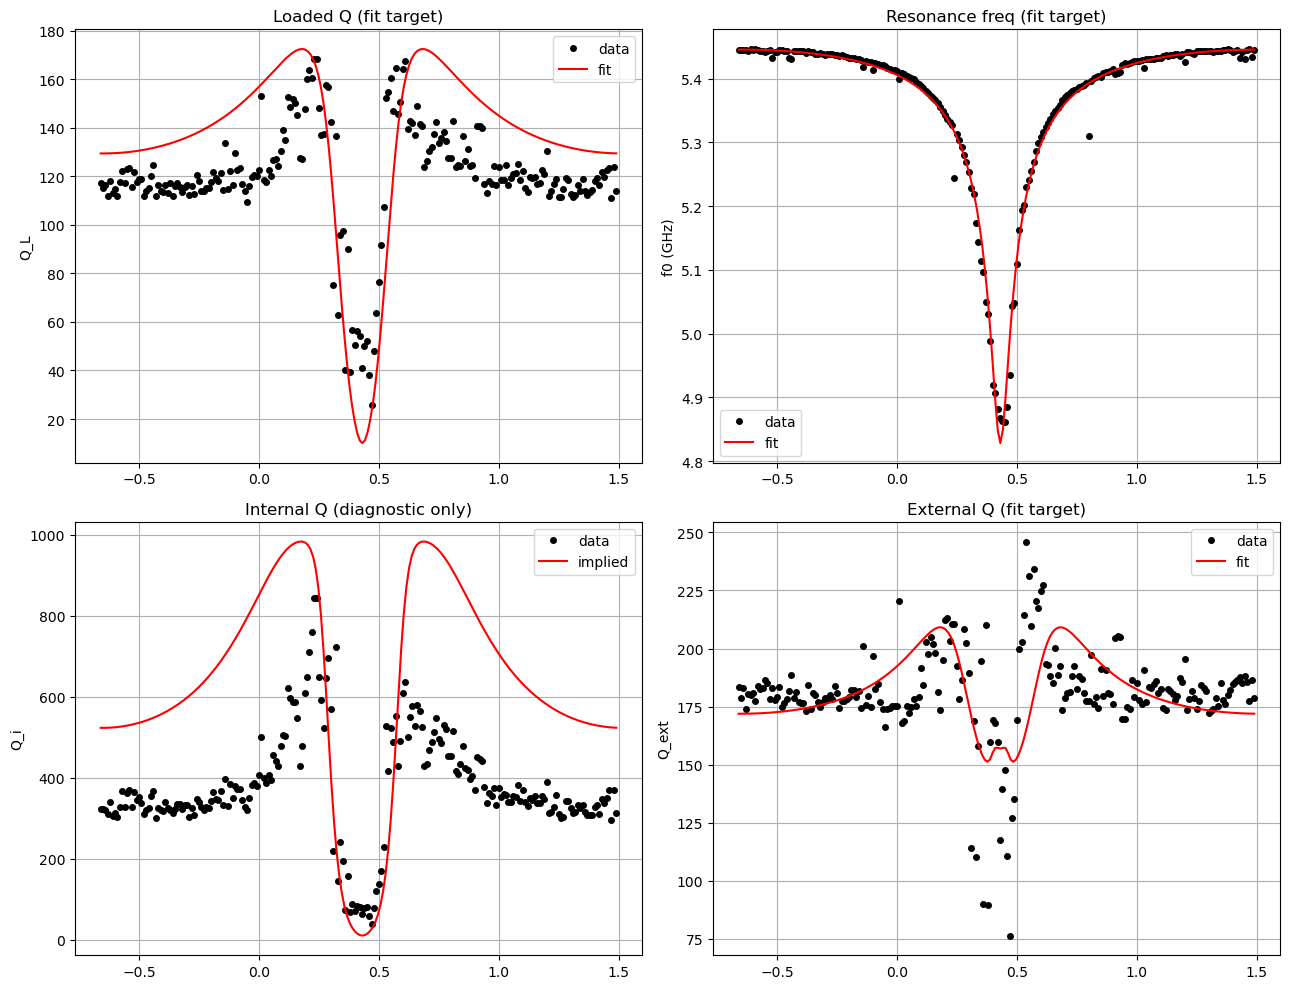

Fitted parameters:
  L0    = 1.67938e-10
  LT    = 4.13459e-10
  L_l   = 4.92857e-07
  C_l   = 1.23829e-10
  C_c   = 6.6123e-14
  R_j   = 19.5978
  M     = 2.89984e+06


In [28]:
I_plot_uA = np.linspace(I_data.min(), I_data.max(), 200)
I_plot_A = I_plot_uA * 1e-6

# QL_model, qi_model, qc_model, f0_model = model_q_factors_rt(
#     I_plot_A, L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, O_fixed, R_L,
#     (df['f0'].min()*0.97, df['f0'].max()*1.03)
# )

QL_model, q_i_model, q_e_model, f0_model = model_q_factors(
    I_plot_A, L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, O_fixed, R_L,
   (df['f0'].min()*0.97, df['f0'].max()*1.03)
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].plot(I_data, X, 'ko', ms=4, label='data')
axes[0,0].plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='fit')
axes[0,0].set_ylabel('Q_L'); axes[0,0].set_title('Loaded Q (fit target)'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(I_data, F/1e9, 'ko', ms=4, label='data')
axes[0,1].plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='fit')
axes[0,1].set_ylabel('f0 (GHz)'); axes[0,1].set_title('Resonance freq (fit target)'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(I_data, Y, 'ko', ms=4, label='data')
axes[1,0].plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='implied')
axes[1,0].set_ylabel('Q_i'); axes[1,0].set_yscale('linear')
axes[1,0].set_title('Internal Q (diagnostic only)'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(I_data, Z, 'ko', ms=4, label='data')
axes[1,1].plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='fit')
axes[1,1].set_ylabel('Q_ext'); axes[1,1].set_title('External Q (fit target)'); axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.show()

param_names = ['L0','LT','L_l','C_l','C_c','R_j','M']
print("Fitted parameters:")
for name, val in zip(param_names, res.x):
    print(f"  {name:5s} = {val:.6g}")
